# Metrics examples

This notebook shows what each of the metrics in [`icenet_mp.metrics`](../icenet_mp/metrics/) captures, using a small synthetic sea ice concentration field.

The metrics compared:

- **`IceNetAccuracyPerForecastDay`** — binary classification accuracy (ice / no ice) after thresholding concentration at 0.15.
- **`MAEPerForecastDay`** / **`RMSEPerForecastDay`** — pixel-wise concentration error, averaged (MAE) or root-mean-squared (RMSE).
- **`SeaIceExtentErrorPerForecastDay`** — absolute difference between predicted and true total ice area (km²), summed over the whole field.

All four are computed per forecast lead time (day 0, 1, 2, ...) from `(batch, time, channel, height, width)` tensors.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from icenet_mp.metrics import (
    IceNetAccuracyPerForecastDay,
    MAEPerForecastDay,
    RMSEPerForecastDay,
    SeaIceExtentErrorPerForecastDay,
)

# Categorical colours, used in fixed order so a scenario always maps to the same colour
SCENARIO_COLORS = {
    "perfect": "#2a78d6",
    "overestimate extent": "#eb6834",
    "underestimate extent": "#1baf7a",
    "persistence": "#eda100",
    "shifted edge": "#4a3aa7",
    "noisy": "#e87ba4",
}
CONCENTRATION_CMAP = "Blues"

/var/folders/xr/xjkpw26d2gqgfzz06tkmfr5c0000gr/T/ipykernel_89041/2837458945.py:6: UserWarning: PYTORCH_ENABLE_MPS_FALLBACK was set after torch was imported. This means that it might not have any effect. If you have problems, please try setting this environment variable before importing torch.
  from icenet_mp.metrics import (


## Synthetic "truth"

The truth is a circular ice cap, centred in the domain, whose radius shrinks over the forecast (a stand-in for melt). Concentration transitions smoothly from 1 (ice) to 0 (open water) at the edge, as it would in real OSISAF-style data.

In [2]:
GRID_SIZE = 40
N_DAYS = 6
CENTER = (GRID_SIZE / 2, GRID_SIZE / 2)
RADIUS_START = 15.0
RADIUS_END = 8.0
EDGE_WIDTH = 2.0  # controls how sharp the ice edge is


def ice_field(
    grid_size: int, center: tuple[float, float], radius: float, edge_width: float = EDGE_WIDTH
) -> np.ndarray:
    """Smooth circular ice concentration field in [0, 1], centred at `center`."""
    yy, xx = np.indices((grid_size, grid_size))
    dist = np.sqrt((xx - center[0]) ** 2 + (yy - center[1]) ** 2)
    return 0.5 * (1 - np.tanh((dist - radius) / edge_width))


def to_tensor(field_stack: np.ndarray) -> torch.Tensor:
    """(time, height, width) array -> (batch=1, time, channel=1, height, width) tensor."""
    return torch.from_numpy(field_stack).float()[None, :, None, :, :]


truth_radii = np.linspace(RADIUS_START, RADIUS_END, N_DAYS)
truth = np.stack([ice_field(GRID_SIZE, CENTER, r) for r in truth_radii])
truth_t = to_tensor(truth)

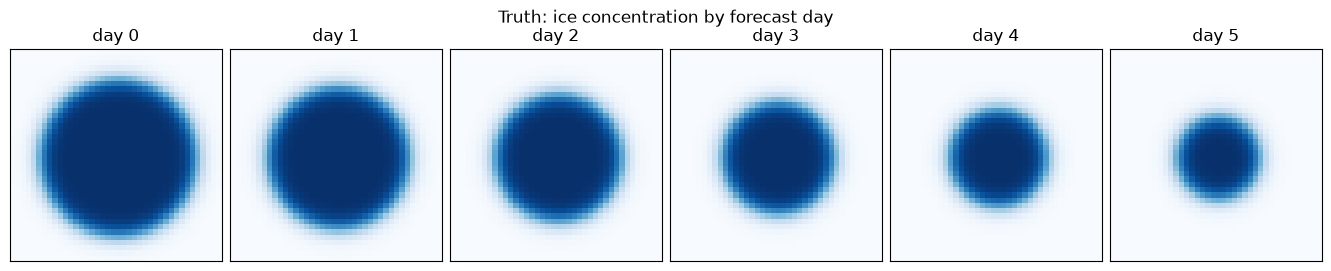

In [3]:
fig, axes = plt.subplots(1, N_DAYS, figsize=(2.2 * N_DAYS, 2.6), constrained_layout=True)
for day, ax in enumerate(axes):
    ax.imshow(truth[day], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
    ax.set_title(f"day {day}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Truth: ice concentration by forecast day")
plt.show()

## Prediction scenarios

Six "forecasts" of the same truth, each getting something different wrong:

- **perfect** — matches the truth exactly (sanity check, all metrics should read 0 / 100%).
- **overestimate extent** — melts too slowly, so too much ice is predicted (a common bias for models that under-predict melt).
- **underestimate extent** — melts too fast, so too little ice is predicted.
- **persistence** — the naive baseline: day-0 truth repeated for every lead time, i.e. "predict no change". Errors should grow with lead time.
- **shifted edge** — the *same* radius (and therefore total area) as the truth each day, but the ice cap is displaced sideways. Total extent is right, but the ice is in the wrong place.
- **noisy** — truth plus small random per-pixel noise, simulating sensor/model noise rather than a systematic error.

In [4]:
scenarios: dict[str, np.ndarray] = {}

scenarios["perfect"] = truth.copy()

slow_melt_radii = np.linspace(
    RADIUS_START, RADIUS_START - 0.5 * (RADIUS_START - RADIUS_END), N_DAYS
)
scenarios["overestimate extent"] = np.stack(
    [ice_field(GRID_SIZE, CENTER, r) for r in slow_melt_radii]
)

fast_melt_radii = np.linspace(RADIUS_START, RADIUS_END - 4.0, N_DAYS)
scenarios["underestimate extent"] = np.stack(
    [ice_field(GRID_SIZE, CENTER, r) for r in fast_melt_radii]
)

scenarios["persistence"] = np.stack([truth[0] for _ in range(N_DAYS)])

SHIFT = (6.0, 0.0)  # pixels; same radius as truth, just moved sideways
shifted_center = (CENTER[0] + SHIFT[0], CENTER[1] + SHIFT[1])
scenarios["shifted edge"] = np.stack(
    [ice_field(GRID_SIZE, shifted_center, r) for r in truth_radii]
)

rng = np.random.default_rng(0)
scenarios["noisy"] = np.clip(truth + rng.normal(0, 0.05, size=truth.shape), 0, 1)

scenario_tensors = {name: to_tensor(field) for name, field in scenarios.items()}

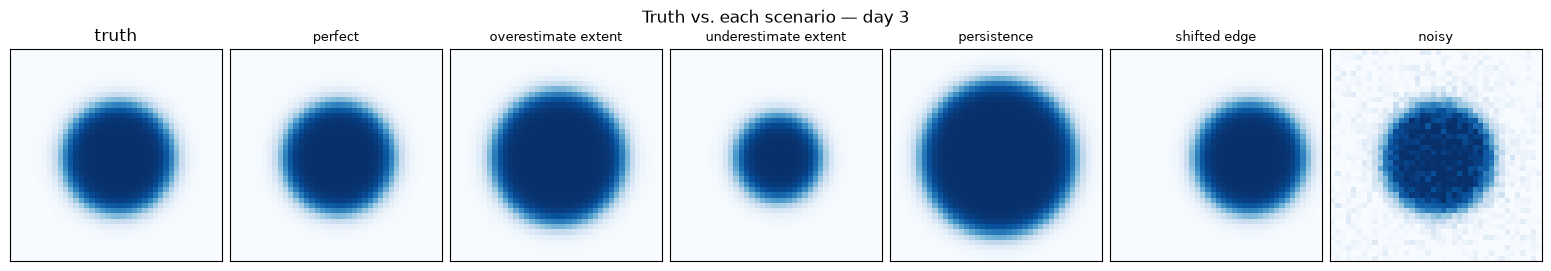

In [5]:
DAY_TO_SHOW = 3

n_scenarios = len(scenarios)
fig, axes = plt.subplots(1, n_scenarios + 1, figsize=(2.2 * (n_scenarios + 1), 2.6), constrained_layout=True)

axes[0].imshow(truth[DAY_TO_SHOW], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[0].set_title("truth")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

for ax, (name, field) in zip(axes[1:], scenarios.items(), strict=True):
    ax.imshow(field[DAY_TO_SHOW], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
    ax.set_title(name, fontsize=9)

fig.suptitle(f"Truth vs. each scenario — day {DAY_TO_SHOW}")
plt.show()

## Computing the metrics

Each metric is a `torchmetrics.Metric`: create it, `update()` with predictions and target, then `compute()` to get one value per forecast day.

In [6]:
METRIC_CLASSES = {
    "accuracy (%)": IceNetAccuracyPerForecastDay,
    "mae": MAEPerForecastDay,
    "rmse": RMSEPerForecastDay,
    "sieerror (km²)": SeaIceExtentErrorPerForecastDay,
}

daily_results: dict[str, dict[str, np.ndarray]] = {}
for name, pred_t in scenario_tensors.items():
    daily_results[name] = {}
    for metric_name, metric_cls in METRIC_CLASSES.items():
        metric = metric_cls()
        metric.update(pred_t, truth_t)
        daily_results[name][metric_name] = metric.compute().numpy()

summary = pd.DataFrame(
    {
        metric_name: [daily_results[name][metric_name].mean() for name in scenarios]
        for metric_name in METRIC_CLASSES
    },
    index=list(scenarios.keys()),
)
summary.index.name = "scenario"
summary.round(3)

,accuracy (%),mae,rmse,sieerror (km²)
scenario,,,,
perfect,100.000000,0.000,0.000,0.000000
overestimate extent,91.083000,0.077,0.142,89166.664062
underestimate extent,92.000000,0.066,0.138,-80000.000000
persistence,80.708000,0.171,0.270,192916.671875
shifted edge,81.030998,0.167,0.309,-6562.500000
noisy,98.103996,0.028,0.040,3125.000000


## How each metric evolves with lead time

Each metric gets its own chart (never a shared/dual axis, since they're on different scales). Watch **persistence** grow steadily as the truth diverges from day 0, and compare **shifted edge** across charts — it's one of the worst scenarios for accuracy/RMSE but among the best for SIE error, since that metric only sees total area, not position.

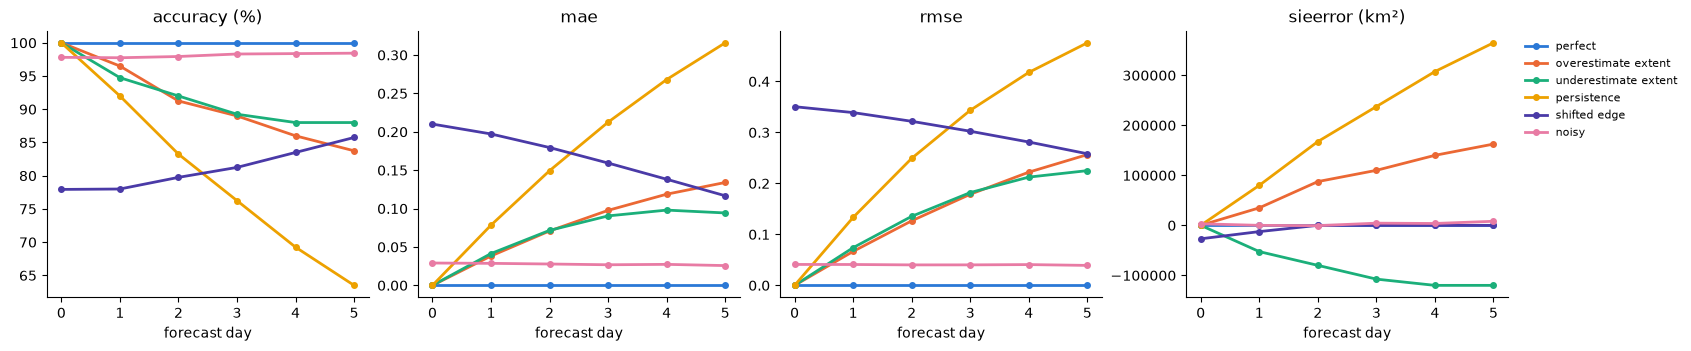

In [7]:
fig, axes = plt.subplots(1, len(METRIC_CLASSES), figsize=(4.2 * len(METRIC_CLASSES), 3.4), constrained_layout=True)

for ax, metric_name in zip(axes, METRIC_CLASSES, strict=True):
    for scenario_name in scenarios:
        ax.plot(
            range(N_DAYS),
            daily_results[scenario_name][metric_name],
            marker="o",
            markersize=4,
            linewidth=2,
            color=SCENARIO_COLORS[scenario_name],
            label=scenario_name,
        )
    ax.set_title(metric_name)
    ax.set_xlabel("forecast day")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

## Takeaways

- **`IceNetAccuracyPerForecastDay`** only cares which side of the 0.15 threshold each pixel lands on. It's insensitive to *how wrong* a prediction is within a class (the `noisy` scenario scores 98%+ despite non-zero MAE/RMSE), but it does penalise the `shifted edge` scenario heavily, since displaced ice puts pixels on the wrong side of the threshold.
- **`MAEPerForecastDay`** / **`RMSEPerForecastDay`** measure pixel-wise concentration error directly. RMSE weights large errors more than MAE, so it separates scenarios with a few big misses (`shifted edge`) from scenarios with many small ones (`noisy`) more sharply than MAE does.
- **`SeaIceExtentErrorPerForecastDay`** only looks at *total* ice area, summed over the whole field. This makes it the right metric for extent-focused validation (e.g. comparing against NSIDC-style sea ice extent), but it's blind to spatial displacement: `shifted edge` has the *same* area as the truth every day, so its SIE error is near zero even though it's one of the worst scenarios by every other metric. Because area errors partially cancel across the field, SIE error can also under-report scenarios with compensating over/under-estimates elsewhere in the domain. It should not be used by itself, but it is a useful when combined with accuracy to see areas of over / under prediction.
- No single metric tells the whole story — a model that looks good on one can look bad on another. Report more than one, and pick the one that matches what actually matters for the use case (classification, magnitude, or aggregate extent).